In [ ]:
# Lightweight path setup for local Jupyter, VS Code, or Colab runs.
# It keeps the notebook runnable whether you start it from this folder or the repo root.
from pathlib import Path
import os

FOLDER_NAME = '01-Regression-Analysis'
NOTEBOOK_NAME = 'Project04_Gradient-Descent.ipynb'

candidates = [
    Path.cwd(),
    Path.cwd() / FOLDER_NAME,
    Path.cwd() / "10-deep_learning" / FOLDER_NAME,
    Path.cwd().parent / FOLDER_NAME,
    Path.cwd().parent / "10-deep_learning" / FOLDER_NAME,
]

for candidate in candidates:
    if (candidate / NOTEBOOK_NAME).exists():
        os.chdir(candidate)
        break

print("Working directory:", Path.cwd().resolve())


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')

# Importing Data

In [4]:
data = pd.read_csv('Regression_Data.csv')
data

,Ind_Data,Dependent_Data
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


# Extracting Dependent and Independent Variables

In [5]:
X = data['Ind_Data'].values
y = data['Dependent_Data'].values

# Visualize the Scatter plot between X and y

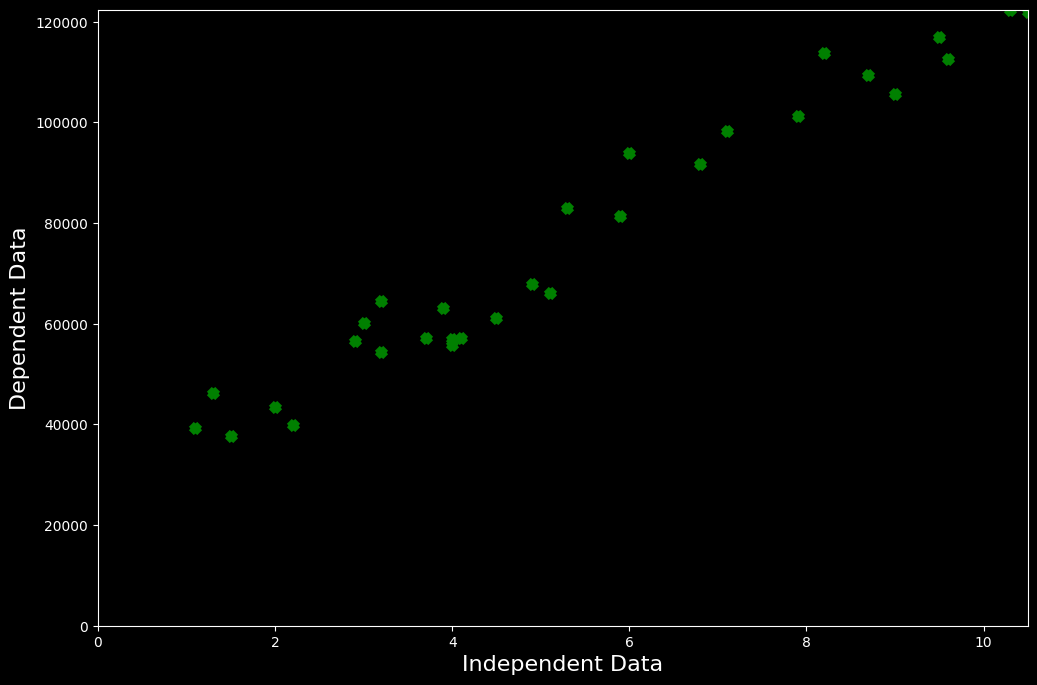

In [6]:
plt.figure(figsize=(12,8))
plt.scatter(X, y, marker = "x", color = 'g', lw = 5)
plt.xlabel('Independent Data', fontsize = 16)
plt.ylabel('Dependent Data', fontsize = 16)
plt.xlim([0, X.max()])
plt.ylim([0, y.max()])
plt.show()

# Reshaping X and y and appending ones at the first column of X

In [7]:
X = X.reshape(-1,1)

In [8]:
y = y.reshape(-1,1)

In [9]:
ones = np.ones((len(X),1))

In [10]:
X_input = np.concatenate((ones,X),axis=1)
X_input

array([[ 1. ,  1.1],
       [ 1. ,  1.3],
       [ 1. ,  1.5],
       [ 1. ,  2. ],
       [ 1. ,  2.2],
       [ 1. ,  2.9],
       [ 1. ,  3. ],
       [ 1. ,  3.2],
       [ 1. ,  3.2],
       [ 1. ,  3.7],
       [ 1. ,  3.9],
       [ 1. ,  4. ],
       [ 1. ,  4. ],
       [ 1. ,  4.1],
       [ 1. ,  4.5],
       [ 1. ,  4.9],
       [ 1. ,  5.1],
       [ 1. ,  5.3],
       [ 1. ,  5.9],
       [ 1. ,  6. ],
       [ 1. ,  6.8],
       [ 1. ,  7.1],
       [ 1. ,  7.9],
       [ 1. ,  8.2],
       [ 1. ,  8.7],
       [ 1. ,  9. ],
       [ 1. ,  9.5],
       [ 1. ,  9.6],
       [ 1. , 10.3],
       [ 1. , 10.5]])

In [12]:
weights = np.random.randn(len(X[0])+1, 1)  # Initialize the values of weights
weights

array([[-0.05451327],
       [-0.1973456 ]])

#Equation of Gradient Descent

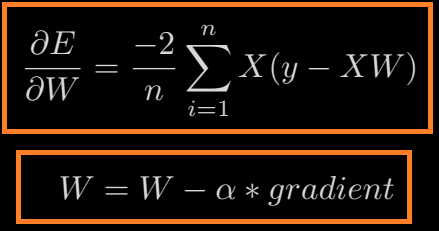

# Applying Gradient Descent

In [13]:
weights = np.random.randn(len(X[0])+1, 1)  # Initialize the values of weights
n = len(X)
iterations = 3000
learningrate = 0.01
for i in range(iterations):
    gradients = -2/n * np.dot(X_input.T,(y - np.dot(X_input, weights)))    # Gradient Calculation
    weights = weights - learningrate * gradients # Weights update

In [14]:
weights

array([[25792.12870984],
       [ 9449.9729301 ]])

# Testing and Evaluating the Model Evaluation

In [15]:
test_data = np.linspace(0,11,30).reshape(-1,1)

In [16]:
test_data

array([[ 0.        ],
       [ 0.37931034],
       [ 0.75862069],
       [ 1.13793103],
       [ 1.51724138],
       [ 1.89655172],
       [ 2.27586207],
       [ 2.65517241],
       [ 3.03448276],
       [ 3.4137931 ],
       [ 3.79310345],
       [ 4.17241379],
       [ 4.55172414],
       [ 4.93103448],
       [ 5.31034483],
       [ 5.68965517],
       [ 6.06896552],
       [ 6.44827586],
       [ 6.82758621],
       [ 7.20689655],
       [ 7.5862069 ],
       [ 7.96551724],
       [ 8.34482759],
       [ 8.72413793],
       [ 9.10344828],
       [ 9.48275862],
       [ 9.86206897],
       [10.24137931],
       [10.62068966],
       [11.        ]])

In [17]:
ones = np.ones((len(test_data),1))

In [18]:
X_test = np.concatenate((ones,test_data),axis=1)

In [19]:
X_test

array([[ 1.        ,  0.        ],
       [ 1.        ,  0.37931034],
       [ 1.        ,  0.75862069],
       [ 1.        ,  1.13793103],
       [ 1.        ,  1.51724138],
       [ 1.        ,  1.89655172],
       [ 1.        ,  2.27586207],
       [ 1.        ,  2.65517241],
       [ 1.        ,  3.03448276],
       [ 1.        ,  3.4137931 ],
       [ 1.        ,  3.79310345],
       [ 1.        ,  4.17241379],
       [ 1.        ,  4.55172414],
       [ 1.        ,  4.93103448],
       [ 1.        ,  5.31034483],
       [ 1.        ,  5.68965517],
       [ 1.        ,  6.06896552],
       [ 1.        ,  6.44827586],
       [ 1.        ,  6.82758621],
       [ 1.        ,  7.20689655],
       [ 1.        ,  7.5862069 ],
       [ 1.        ,  7.96551724],
       [ 1.        ,  8.34482759],
       [ 1.        ,  8.72413793],
       [ 1.        ,  9.10344828],
       [ 1.        ,  9.48275862],
       [ 1.        ,  9.86206897],
       [ 1.        , 10.24137931],
       [ 1.        ,

In [23]:
y_test = np.linspace(np.min(y), np.max(y), 30)

In [20]:
y_pred = np.dot(X_test, weights)  # y_pred = X * W

# Visualizing the Model Performance

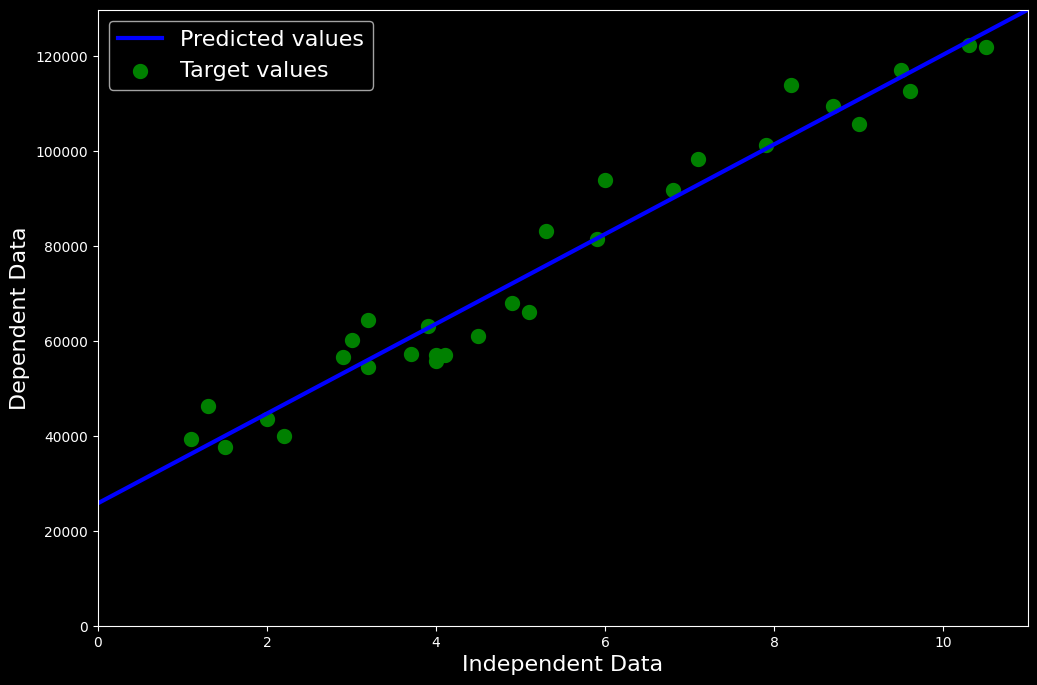

In [21]:
plt.figure(figsize=(12,8))
plt.xlim([0, X_test.max()])
plt.ylim([0, y_pred.max()])
plt.plot(test_data, y_pred, color='blue', label='Predicted values', linewidth = 3)
plt.scatter(X, y, c='green', label='Target values', linewidth = 5)
plt.xlabel('Independent Data', fontsize = 16)
plt.ylabel('Dependent Data', fontsize = 16)
plt.legend(fontsize = 16)
plt.show()

# Evaluating Regression Metrics

In [24]:
from sklearn import metrics
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))


RMSE: 6197.476061283773
MAE: 5247.971485399787
R2: 0.9398423673094455


# Comparing With Least Square

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()  # instantiate Linear Regression

In [26]:
X = X.reshape(-1,1)

In [27]:
lr.fit(X,y)  # Sk-Learn also does least square fitting
print("Intercept:", lr.intercept_)
print("Coefficient:", lr.coef_)

Intercept: [25792.20019867]
Coefficient: [[9449.96232146]]


In [28]:
test_data = test_data.reshape(-1,1)

In [29]:
y_pred = lr.predict(test_data)

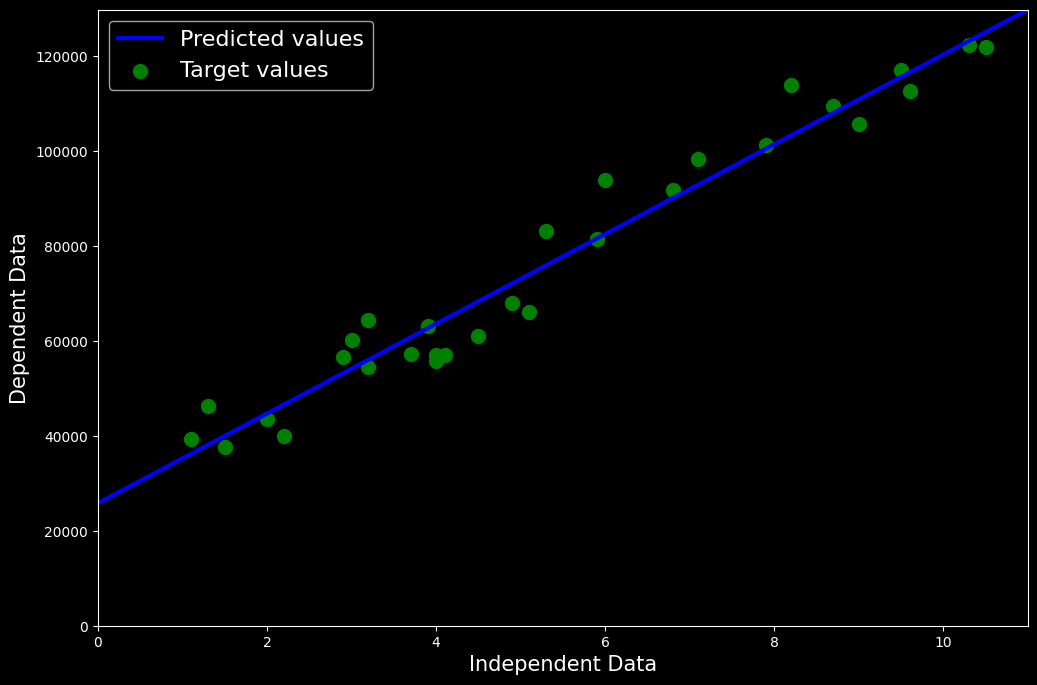

In [30]:
plt.figure(figsize=(12,8))
plt.xlim([0, test_data.max()])
plt.ylim([0, y_pred.max()])
plt.plot(test_data, y_pred, color='blue', label='Predicted values', linewidth = 3)
plt.scatter(X, y, c='green', label='Target values', linewidth = 5)
plt.xlabel('Independent Data', fontsize = 15)
plt.ylabel('Dependent Data', fontsize = 15)
plt.legend(fontsize = 16)
plt.show()

In [31]:
from sklearn import metrics
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))


RMSE: 6197.438841666302
MAE: 5247.939884570575
R2: 0.9398430898737059
